In [1]:
from pathlib import Path

import netCDF4
import numpy as np
import xarray as xr

In [2]:
data = Path("data")

In [3]:
import earthkit.plots

from quickplot import quickplot

In [4]:
# Load the data
ds = xr.open_dataset(
    data / "hplp" / "hplp_sfc_regridded_tp_025deg_steps_228_240.nc",
    engine="netcdf4",
    decode_timedelta=True,
)
da = ds["tp"]

In [5]:
eb_rel = 0.01  # 1%

In [6]:
from numcodecs_wasm_sz3 import Sz3

codec = Sz3(eb_mode="rel", eb_rel=eb_rel)

In [7]:
# encode and decode the data
da_enc = codec.encode(da.values)
da_dec = da.copy(data=codec.decode(da_enc))

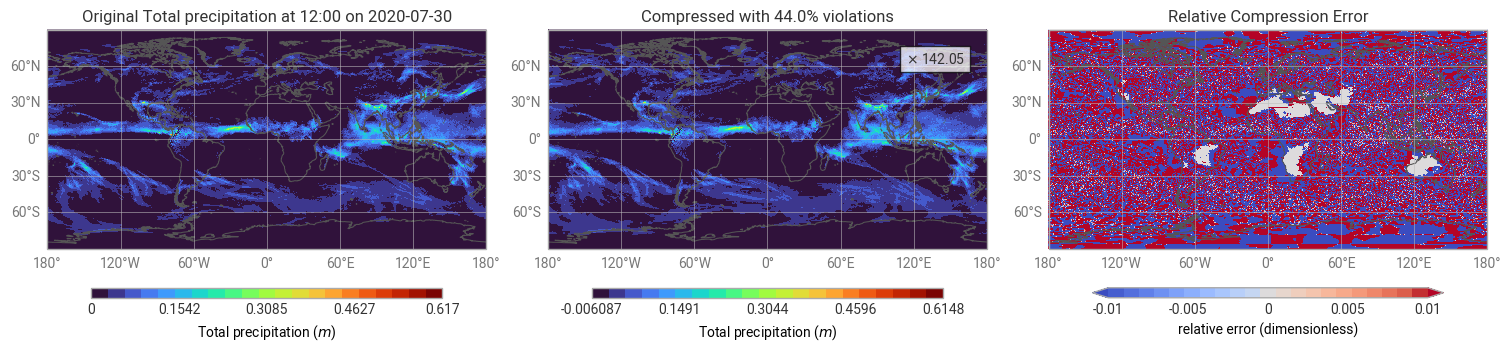

In [8]:
# plot a comparison figure
fig = earthkit.plots.Figure(
    size=(15, 4),
    rows=1,
    columns=3,
)

# violation if
# (a) the relative error bound is exceeded
# (b) incl if zero is not preserved
violations = np.mean(~((da_dec - da) <= (da * eb_rel)))
violations = (
    0
    if violations == 0
    else np.format_float_positional(100 * violations, precision=1, min_digits=1) + "%"
)
if violations == "0.0%":
    violations = "<0.05%"

quickplot(da, fig.add_map(0, 0), title="Original {default_title}")
quickplot(
    da_dec,
    fig.add_map(0, 1),
    title=f"Compressed with {violations} violations",
    cr=da.nbytes / np.array(da_enc).nbytes,
)
quickplot(
    xr.where(da == 0, da_dec == da, (da_dec - da) / da).assign_attrs(
        long_name="relative error", units="%"
    ),
    fig.add_map(0, 2),
    error=True,
    vrange=(-eb_rel, eb_rel),
    title="Relative Compression Error",
)

fig.show()